In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, callbacks

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from google.colab import drive
import zipfile
import os

# Google Drive mount karo
drive.mount('/content/drive')

# ZIP file ka path (Drive me dataset ka exact path do)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os

extract_to = "/content/Snakes_Dataset/Snakes"

print(f"{'Class Name':<45} {'Total Images'}")
print("-" * 55)

total = 0
for class_name in sorted(os.listdir(extract_to)):
    class_path = os.path.join(extract_to, class_name)
    if os.path.isdir(class_path):
        count = len([f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))])
        print(f"{class_name:<45} {count}")
        total += count

print("-" * 55)
print(f"{'TOTAL':<45} {total}")

Class Name                                    Total Images
-------------------------------------------------------
A_Duplicate Folders                           0
Banded Kukri Snake                            11
Black-headed Royal Snake                      12
Blunt-nosed Viper                             11
Brahminy blind snake                          11
Buff-striped keelback                         11
Caspian cobra                                 11
Checkered Keelback                            11
Common Cat Snake                              11
Common Krait                                  11
Common Sand Boa                               11
Common Wolf Snake                             11
Diadem Snake or Royal Snake                   11
Glossy-bellied Racer                          11
Himalayan Pit Viper                           11
Indian Cobra                                  11
Indian wolf snake                             11
Jan’s Cliff Racer                             10
Red 

In [4]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, save_img

input_dir = "/content/Snakes_Dataset/Snakes"
output_dir = "/content/Snakes_Augmented"
TARGET_PER_CLASS = 100
IMG_SIZE = (224, 224)

# Anti-overfit augmentation — aggressive diversity
datagen = ImageDataGenerator(
    rotation_range=60,          # zyada rotation = zyada variety
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.3,
    zoom_range=[0.7, 1.4],      # zoom in aur zoom out dono
    horizontal_flip=True,
    vertical_flip=True,         # snakes ke liye valid
    brightness_range=[0.5, 1.5],# lighting variety
    channel_shift_range=30.0,   # color variation
    fill_mode='reflect'         # nearest se behtar — edge artifacts kam
)

for class_name in os.listdir(input_dir):
    class_input_path = os.path.join(input_dir, class_name)

    if not os.path.isdir(class_input_path) or class_name == "A_Duplicate Folders":
        continue

    class_output_path = os.path.join(output_dir, class_name)
    os.makedirs(class_output_path, exist_ok=True)

    images = []
    for fname in os.listdir(class_input_path):
        fpath = os.path.join(class_input_path, fname)
        if os.path.isfile(fpath) and fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            img = load_img(fpath, target_size=IMG_SIZE)
            images.append(img_to_array(img))

    original_count = len(images)

    # Original images copy karo
    for i, img_array in enumerate(images):
        save_img(os.path.join(class_output_path, f"orig_{i}.jpg"), img_array)

    # Augmented images — har baar alag transformation
    needed = TARGET_PER_CLASS - original_count
    images_np = np.array(images)
    aug_gen = datagen.flow(images_np, batch_size=1, shuffle=True, seed=None)  # seed=None = random har baar

    for i in range(needed):
        aug_img = next(aug_gen)[0]
        save_img(os.path.join(class_output_path, f"aug_{i}.jpg"), aug_img)

    print(f"{class_name}: {original_count} -> {TARGET_PER_CLASS}")

print("\nDone! Output:", output_dir)

Indian Cobra: 11 -> 100
Spectacled Cobra: 11 -> 100
Viperine water snake: 11 -> 100
Common Sand Boa: 11 -> 100
Red Sand Boa: 11 -> 100
Checkered Keelback: 11 -> 100
Banded Kukri Snake: 11 -> 100
Caspian cobra: 11 -> 100
Indian wolf snake: 11 -> 100
Saharan horned viper: 11 -> 100
Russell's Vipe: 11 -> 100
Common Krait: 11 -> 100
Diadem Snake or Royal Snake: 11 -> 100
Brahminy blind snake: 11 -> 100
Jan’s Cliff Racer: 10 -> 100
Wadi Racer, Braid Snake, or Common Cliff Racer: 11 -> 100
Common Wolf Snake: 11 -> 100
Common Cat Snake: 11 -> 100
Himalayan Pit Viper: 11 -> 100
Glossy-bellied Racer: 11 -> 100
Buff-striped keelback: 11 -> 100
Blunt-nosed Viper: 11 -> 100
Black-headed Royal Snake: 12 -> 100
Saw-scaled Viper: 11 -> 100

Done! Output: /content/Snakes_Augmented


In [5]:
DATA_DIR = "/content/Snakes_Augmented"
IMG_SIZE = (224, 224)
BATCH_SIZE = 64
EPOCHS = 30
NUM_CLASSES = len(os.listdir(DATA_DIR))

print(f"Total classes: {NUM_CLASSES}")

Total classes: 24


In [6]:
from sklearn.model_selection import train_test_split
import shutil

# Pehle sab image paths aur labels collect karo
all_images = []
all_labels = []

for class_name in sorted(os.listdir(DATA_DIR)):
    class_path = os.path.join(DATA_DIR, class_name)
    if not os.path.isdir(class_path):
        continue
    for fname in os.listdir(class_path):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_images.append(os.path.join(class_path, fname))
            all_labels.append(class_name)

# 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    all_images, all_labels, test_size=0.30, stratify=all_labels, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

# Split folders banao
for split, paths, labels in [('train', X_train, y_train),
                               ('val',   X_val,   y_val),
                               ('test',  X_test,  y_test)]:
    for fpath, label in zip(paths, labels):
        dest = os.path.join("/content/split_data", split, label)
        os.makedirs(dest, exist_ok=True)
        shutil.copy(fpath, dest)

print("Split complete!")

Train: 1680 | Val: 360 | Test: 360
Split complete!


In [7]:
from tensorflow.keras.applications.efficientnet import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow_from_directory(
    "/content/split_data/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_gen = val_test_datagen.flow_from_directory(
    "/content/split_data/val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    "/content/split_data/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_names = list(train_gen.class_indices.keys())
print("Classes:", class_names)

Found 1680 images belonging to 24 classes.
Found 360 images belonging to 24 classes.
Found 360 images belonging to 24 classes.
Classes: ['Banded Kukri Snake', 'Black-headed Royal Snake', 'Blunt-nosed Viper', 'Brahminy blind snake', 'Buff-striped keelback', 'Caspian cobra', 'Checkered Keelback', 'Common Cat Snake', 'Common Krait', 'Common Sand Boa', 'Common Wolf Snake', 'Diadem Snake or Royal Snake', 'Glossy-bellied Racer', 'Himalayan Pit Viper', 'Indian Cobra', 'Indian wolf snake', 'Jan’s Cliff Racer', 'Red Sand Boa', "Russell's Vipe", 'Saharan horned viper', 'Saw-scaled Viper', 'Spectacled Cobra', 'Viperine water snake', 'Wadi Racer, Braid Snake, or Common Cliff Racer']


In [8]:
# Pehle session clear karo
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras import layers, models

# EfficientNetB3 ke liye sahi preprocessing
from tensorflow.keras.applications.efficientnet import preprocess_input

base_model = EfficientNetB3(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Sirf last 20 layers trainable rakho — poora freeze mat karo
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = preprocess_input(inputs)          # EfficientNet ka apna preprocessing
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = tf.keras.Model(inputs, x)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),  # LR bhi kam kiya
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 7, 7, 1536)     │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         6,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,189,319 (42.68 MB)

 Trainable params: 3,775,864 (14.40 MB)

 Non-trainable params: 7,413,455 (28.28 MB)

In [9]:
from tensorflow.keras import callbacks

print("Phase 1: Frozen base model training...\n")

cb_list = [
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath='/content/best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

history1 = model.fit(
    train_gen,
    epochs=8,
    validation_data=val_gen,
    callbacks=cb_list
)

Phase 1: Frozen base model training...

Epoch 1/8
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.0598 - loss: 3.9414
Epoch 1: val_accuracy improved from None to 0.29444, saving model to /content/best_model.keras

Epoch 1: finished saving model to /content/best_model.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 149s 3s/step - accuracy: 0.0946 - loss: 3.6247 - val_accuracy: 0.2944 - val_loss: 2.8208 - learning_rate: 1.0000e-04
Epoch 2/8
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 875ms/step - accuracy: 0.2738 - loss: 2.6209
Epoch 2: val_accuracy improved from 0.29444 to 0.49444, saving model to /content/best_model.keras

Epoch 2: finished saving model to /content/best_model.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 27s 989ms/step - accuracy: 0.3000 - loss: 2.4722 - val_accuracy: 0.4944 - val_loss: 2.3941 - learning_rate: 1.0000e-04
Epoch 3/8
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 835ms/step - accuracy: 0.4430 - loss: 1.8993
Epoch 3: val_accuracy improved from 0.49444 to 0.64444, saving model to /content/best_model.keras

Epoc

In [10]:
# Last 30 layers unfreeze karo
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Lower LR se recompile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cb_list2 = [
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath='/content/best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("Phase 2: Fine tuning...\n")

history2 = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    callbacks=cb_list2
)

Phase 2: Fine tuning...

Epoch 1/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8397 - loss: 0.5796
Epoch 1: val_accuracy improved from None to 0.88889, saving model to /content/best_model.keras

Epoch 1: finished saving model to /content/best_model.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 115s 3s/step - accuracy: 0.8452 - loss: 0.5659 - val_accuracy: 0.8889 - val_loss: 0.6782 - learning_rate: 1.0000e-05
Epoch 2/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 941ms/step - accuracy: 0.8538 - loss: 0.5674
Epoch 2: val_accuracy improved from 0.88889 to 0.89444, saving model to /content/best_model.keras

Epoch 2: finished saving model to /content/best_model.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.8595 - loss: 0.5453 - val_accuracy: 0.8944 - val_loss: 0.6191 - learning_rate: 1.0000e-05
Epoch 3/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 912ms/step - accuracy: 0.8595 - loss: 0.5412
Epoch 3: val_accuracy did not improve from 0.89444
27/27 ━━━━━━━━━━━━━━━━━━━━ 26s 955ms/step - accuracy: 0.8560 - loss

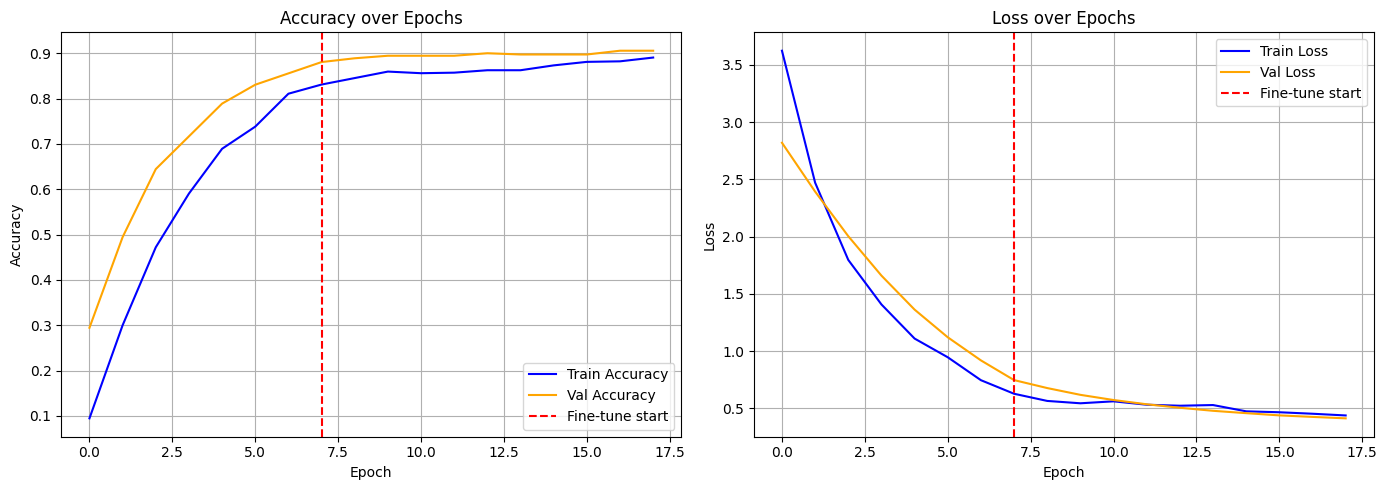

In [11]:
import matplotlib.pyplot as plt

# Dono histories merge karo
def merge_history(h1, h2):
    merged = {}
    for key in h1.history:
        merged[key] = h1.history[key] + h2.history[key]
    return merged

hist = merge_history(history1, history2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy graph
axes[0].plot(hist['accuracy'], label='Train Accuracy', color='blue')
axes[0].plot(hist['val_accuracy'], label='Val Accuracy', color='orange')
axes[0].axvline(x=len(history1.history['accuracy'])-1,
                color='red', linestyle='--', label='Fine-tune start')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss graph
axes[1].plot(hist['loss'], label='Train Loss', color='blue')
axes[1].plot(hist['val_loss'], label='Val Loss', color='orange')
axes[1].axvline(x=len(history1.history['loss'])-1,
                color='red', linestyle='--', label='Fine-tune start')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150)
plt.show()

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 208ms/step - accuracy: 0.9194 - loss: 0.3664

Test Accuracy: 91.94%
Test Loss:     0.3664
6/6 ━━━━━━━━━━━━━━━━━━━━ 29s 3s/step

Classification Report:

                                                precision    recall  f1-score   support

                            Banded Kukri Snake       1.00      1.00      1.00        15
                      Black-headed Royal Snake       1.00      0.93      0.97        15
                             Blunt-nosed Viper       1.00      1.00      1.00        15
                          Brahminy blind snake       0.93      0.93      0.93        15
                         Buff-striped keelback       1.00      0.93      0.97        15
                                 Caspian cobra       1.00      0.67      0.80        15
                            Checkered Keelback       1.00      0.80      0.89        15
                              Common Cat Snake       0.94      1.00      0.97        15
                           

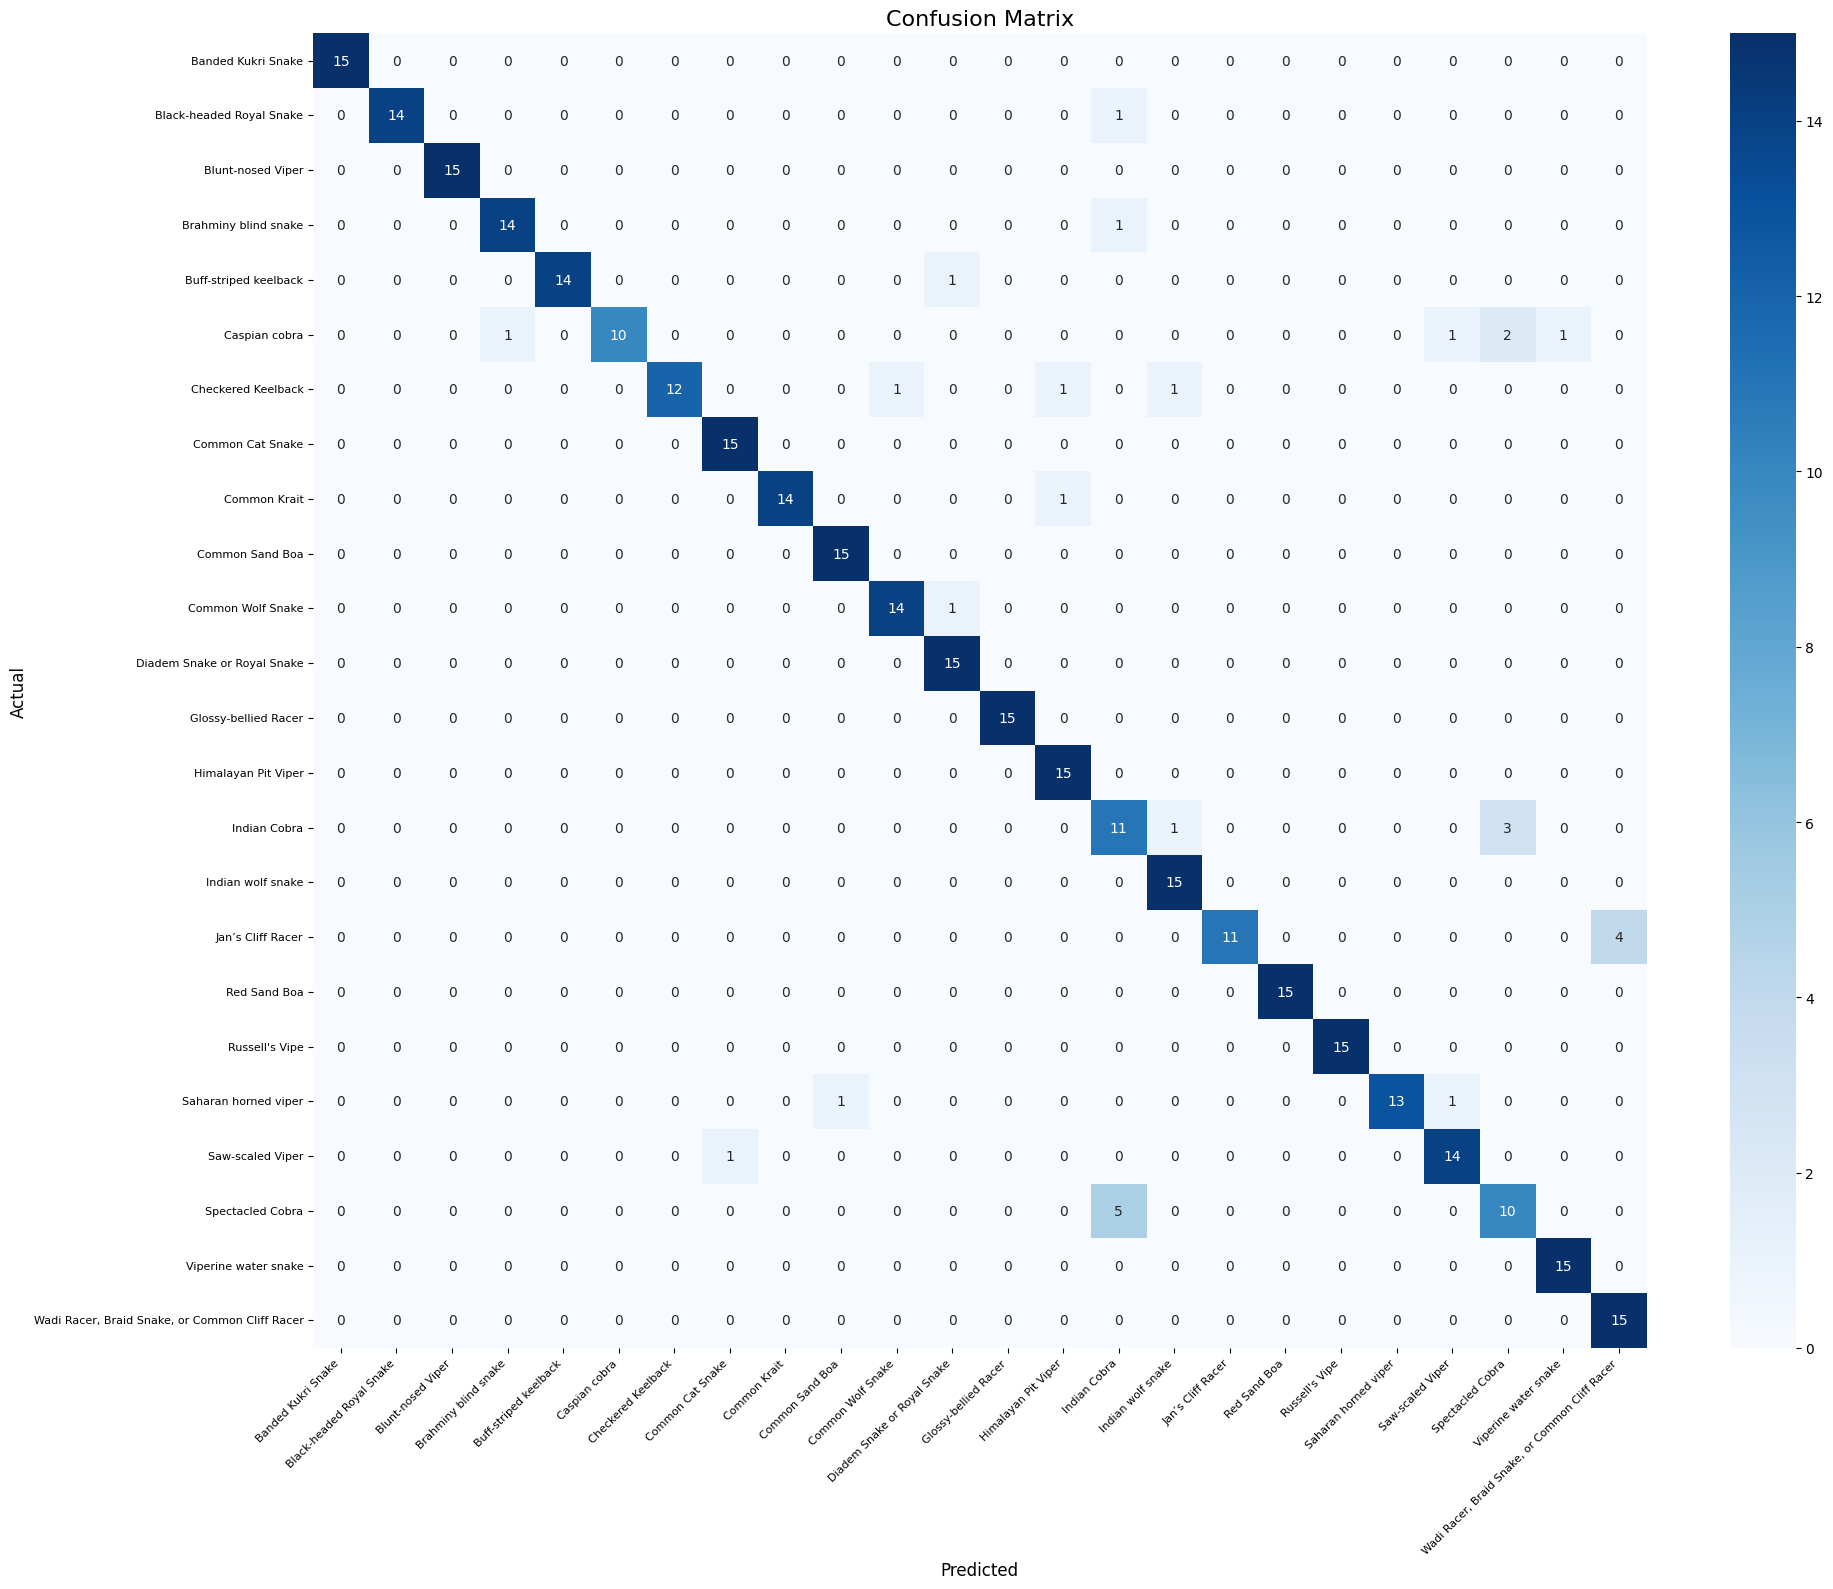

In [12]:
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Test set evaluate
test_loss, test_acc = model.evaluate(test_gen, verbose=1)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss:     {test_loss:.4f}")

# Predictions
test_gen.reset()
y_pred_probs = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(20, 16))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150)
plt.show()

In [13]:
from google.colab import files

files.download('/content/best_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

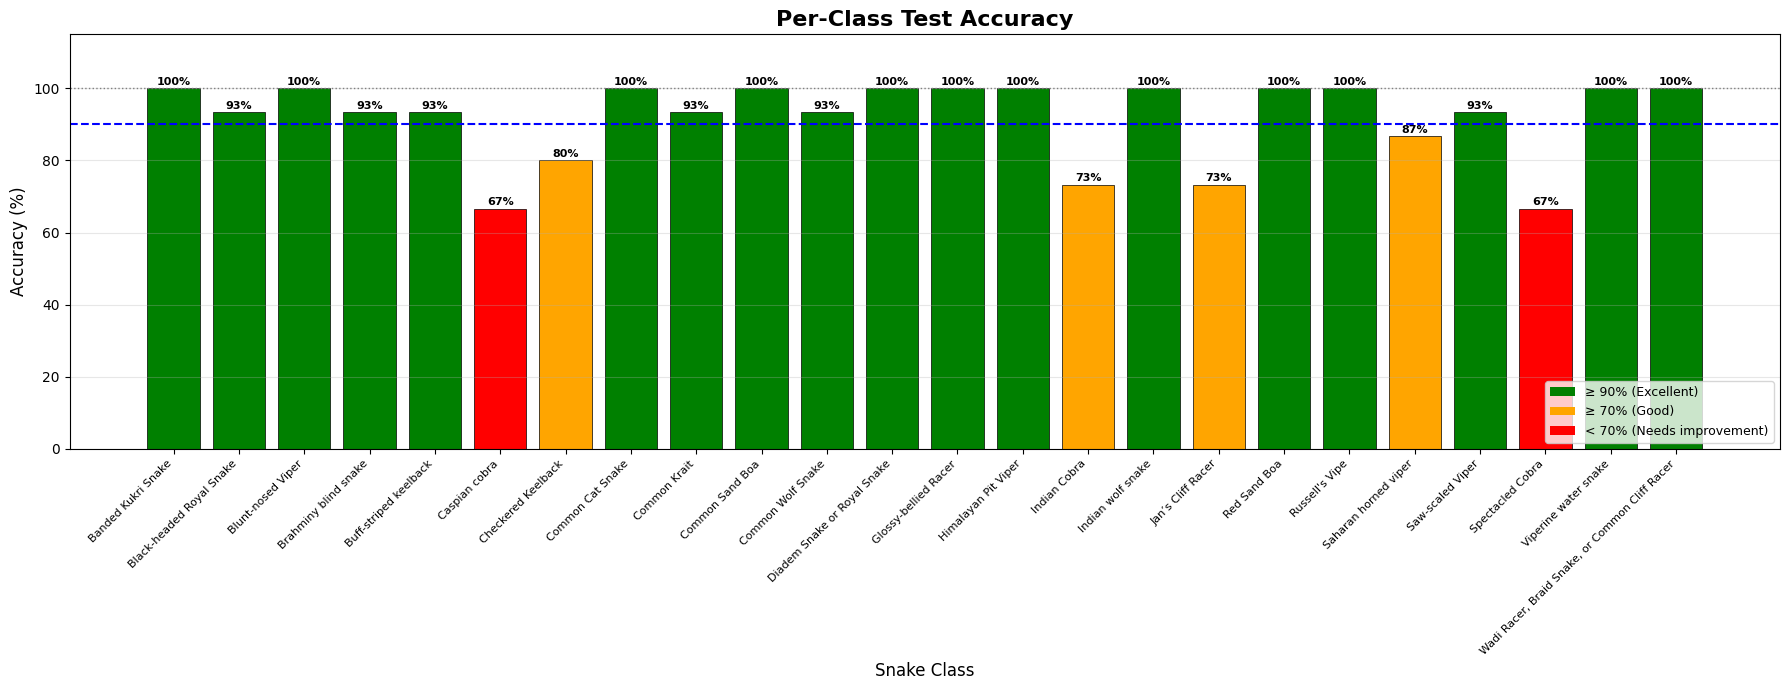


Overall Test Accuracy: 92%


In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Class wise accuracy nikalo
cm_values = [15,14,15,14,14,10,12,15,14,15,14,15,15,15,11,15,11,15,15,13,14,10,15,15]
total_per_class = 15

class_accuracy = [correct/total_per_class * 100 for correct in cm_values]

# Colors — green if >=90, orange if >=70, red if <70
colors = ['green' if acc >= 90 else 'orange' if acc >= 70 else 'red' for acc in class_accuracy]

plt.figure(figsize=(18, 7))
bars = plt.bar(class_names, class_accuracy, color=colors, edgecolor='black', linewidth=0.5)

# Value labels bar ke upar
for bar, acc in zip(bars, class_accuracy):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc:.0f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

# 90% reference line
plt.axhline(y=90, color='blue', linestyle='--', linewidth=1.5, label='90% threshold')
plt.axhline(y=100, color='gray', linestyle=':', linewidth=1, label='100% line')

plt.title('Per-Class Test Accuracy', fontsize=16, fontweight='bold')
plt.xlabel('Snake Class', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.ylim(0, 115)
plt.legend(fontsize=10)
plt.grid(axis='y', alpha=0.3)

# Color legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='green', label='≥ 90% (Excellent)'),
                   Patch(facecolor='orange', label='≥ 70% (Good)'),
                   Patch(facecolor='red', label='< 70% (Needs improvement)')]
plt.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('/content/per_class_accuracy.png', dpi=150)
plt.show()

print(f"\nOverall Test Accuracy: 92%")

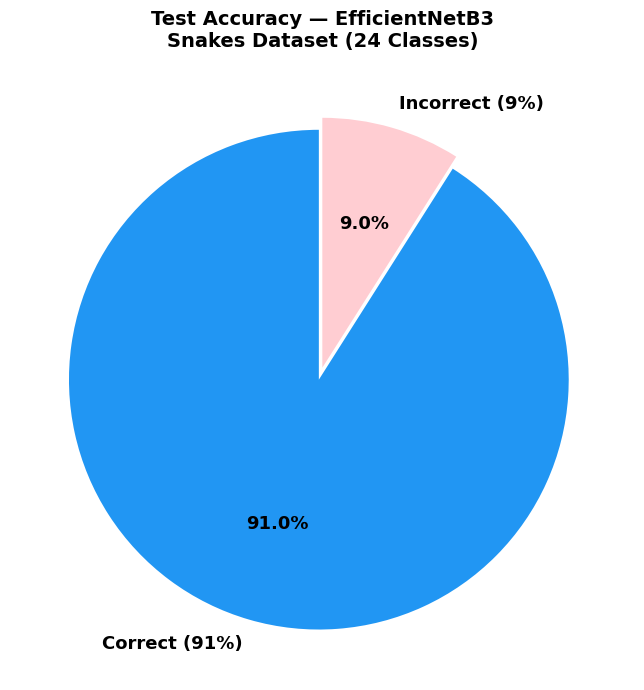

In [15]:
import matplotlib.pyplot as plt

labels = ['Correct (91%)', 'Incorrect (9%)']
sizes = [91, 9]
colors = ['#2196F3', '#FFCDD2']
explode = (0.05, 0)

plt.figure(figsize=(7, 7))
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', startangle=90,
        textprops={'fontsize': 13, 'fontweight': 'bold'})

plt.title('Test Accuracy — EfficientNetB3\nSnakes Dataset (24 Classes)',
          fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/test_accuracy_pie.png', dpi=150)
plt.show()